# 02. Моделирование (промежуточные эксперименты)

Здесь можно повторить шаги пайплайна вручную: предобработка → обучение → метрики.  
Полный автоматический прогон делается через `python main.py` в корне проекта.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import utils
import data_preprocessing
import train_models
import evaluate_models

utils.ensure_directories()
_, _ = utils.ensure_raw_datasets_exist()

In [2]:
import pandas as pd

df = pd.read_csv(ROOT / "data" / "raw" / "kazakhstan_credit.csv", encoding="utf-8")
prep = data_preprocessing.preprocess_dataframe(df, test_size=0.25, random_state=42)
print("Train:", prep.X_train.shape, "Test:", prep.X_test.shape)

Train: (22500, 42) Test: (7500, 42)


In [3]:
models_dir = ROOT / "models" / "notebook_kz"
fitted = train_models.train_all(prep.X_train, prep.y_train, models_dir=models_dir)
table, detailed = evaluate_models.evaluate_all_models(fitted, prep.X_test, prep.y_test)
table

,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.6173,0.1251,0.5874,0.2063,0.6480
1,decision_tree,0.6748,0.1753,0.7669,0.2854,0.7873
2,random_forest,0.9677,0.7869,0.8488,0.8167,0.9883
3,gradient_boosting,0.9204,0.9750,0.0614,0.1156,0.8469


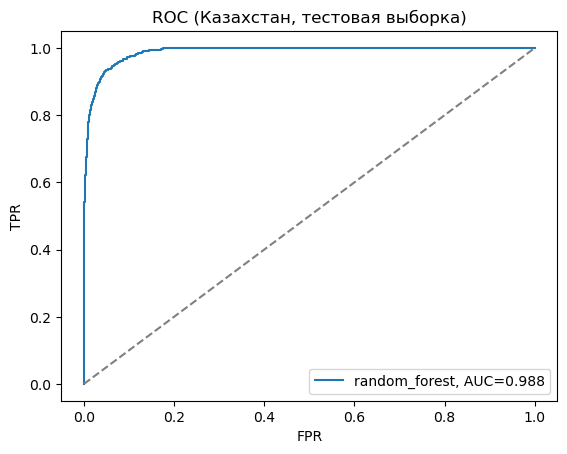

In [4]:
# пример: ROC для случайного леса
import matplotlib.pyplot as plt

name = "random_forest"
res = detailed[name]
plt.plot(res["fpr"], res["tpr"], label=f"{name}, AUC={res['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC (Казахстан, тестовая выборка)")
plt.legend()
plt.show()